# **SetUp**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!gdown "https://drive.google.com/uc?id=19OS7gWyo29K2BJB1lCLbUAzs2DSgvKJF"
!gdown "https://drive.google.com/uc?id=14yAL1tzYzzED8QJglUtTMX_uU7LodSml"
!gdown "https://drive.google.com/uc?id=1jHfrf5uFe7VsBSzrToXSMDxOQGM2Sx_l"
!gdown "https://drive.google.com/uc?id=1KK1XTzsCyje1Y2B2jY4S0UU4Mh33zAYQ"


xauusd_df = pd.read_csv('XAUUSD_Daily_200406110000_202512310000.csv')# XAU/USD
usdthb_df = pd.read_csv('USDTHB_Daily_201106020000_202512310000.csv')# USD/THB exchange rate
vix_df = pd.read_csv('VIX_History.csv')# vix index
gvz_df = pd.read_csv('CBOE_Gold_Volatitity_Historical_Data.csv')# Global Gold Volatility

# 2. Prepare Datetime
xauusd_df['Datetime'] = pd.to_datetime(xauusd_df['<DATE>'], format='%Y.%m.%d')
usdthb_df['Datetime'] = pd.to_datetime(usdthb_df['<DATE>'], format='%Y.%m.%d')
xauusd_df.set_index('Datetime', inplace=True)
usdthb_df.set_index('Datetime', inplace=True)

# 3. Merge data
df = xauusd_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'XAUUSD'}).join(
    usdthb_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'USDTHB'}), how='inner'
)

Downloading...
From: https://drive.google.com/uc?id=19OS7gWyo29K2BJB1lCLbUAzs2DSgvKJF
To: /content/XAUUSD_Daily_200406110000_202512310000.csv
100% 299k/299k [00:00<00:00, 101MB/s]
Downloading...
From: https://drive.google.com/uc?id=14yAL1tzYzzED8QJglUtTMX_uU7LodSml
To: /content/USDTHB_Daily_201106020000_202512310000.csv
100% 198k/198k [00:00<00:00, 86.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jHfrf5uFe7VsBSzrToXSMDxOQGM2Sx_l
To: /content/VIX_History.csv
100% 466k/466k [00:00<00:00, 107MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KK1XTzsCyje1Y2B2jY4S0UU4Mh33zAYQ
To: /content/CBOE_Gold_Volatitity_Historical_Data.csv
100% 189k/189k [00:00<00:00, 75.9MB/s]


# **1. Global Gold Log Returns ($r_{XAU}$)**
This is the baseline directional drift of the global asset.
Why it matters: It tells if the baseline asset is trending up, down, or flat.



*  **Why it matters:** It tells the HMM if the baseline asset is trending up, down, or flat.

*   **Formula:** $r_{XAU, t} = \ln(P_{XAU, t} / P_{XAU, t-1})$





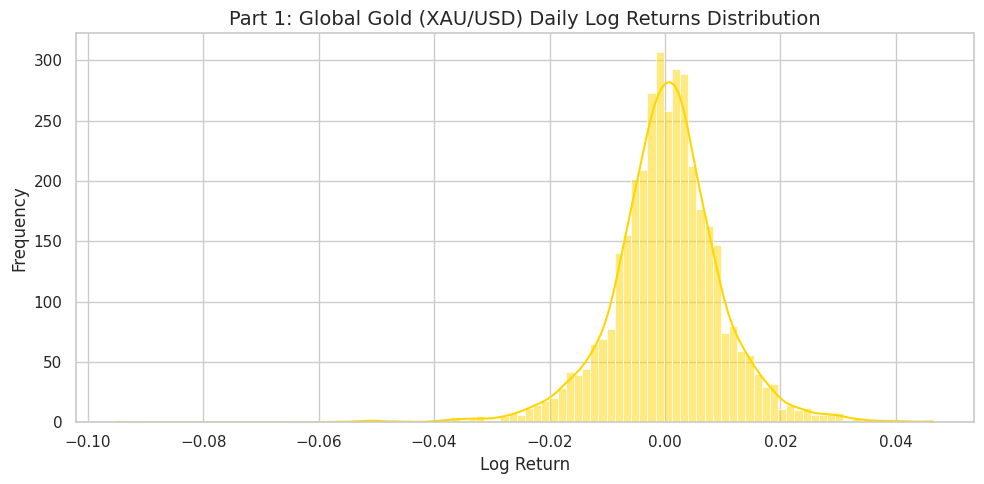

In [3]:
# 4. Calculate Global Gold (XAU/USD) Log Returns
df['XAU_Log_Return'] = np.log(df['XAUUSD'] / df['XAUUSD'].shift(1))

# 5. Plot Log Returns Distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(df['XAU_Log_Return'].dropna(), kde=True, color='gold', bins=100)

plt.title('Part 1: Global Gold (XAU/USD) Daily Log Returns Distribution', fontsize=14)
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **2. Rolling Realized Volatility ($\sigma$)**
This is the single most important feature for an model. Market regimes are defined more by volatility than by direction.




*   **Why it matters:** Bull markets typically have low, steady volatility. Bear markets have massive, explosive volatility. Sideways markets have collapsing volatility. If you don't feed volatility to the HMM, it will fail to separate regimes.
*   **Calculation:** The standard deviation of log returns over a rolling window (e.g., 14 or 20 periods).
*   **Formula:** $\sigma_{t} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (r_{t-i} - \bar{r})^2}$




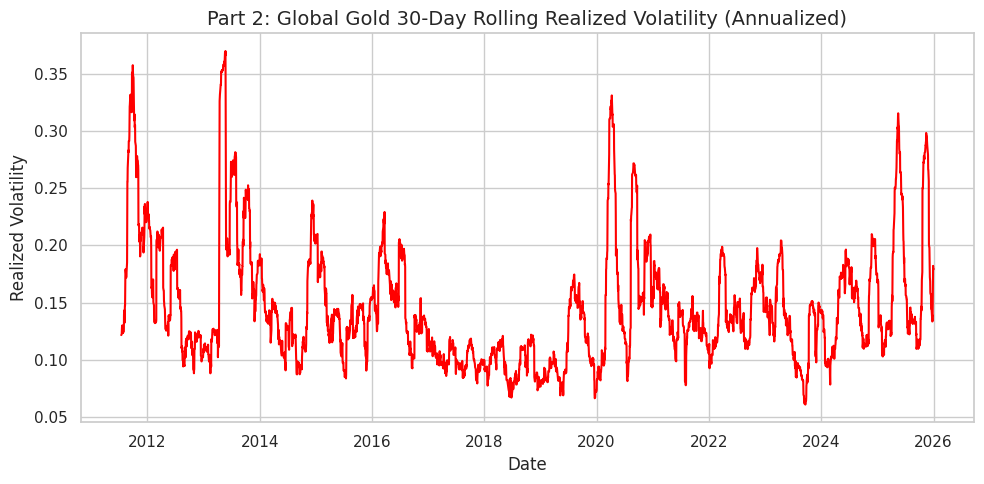

In [4]:
# 1. Calculate 30-Day Rolling Realized Volatility (Annualized)
# Formula: 30-Day Standard Deviation of Log Returns * sqrt(252 trading days)
df['XAU_Volatility_30D'] = df['XAU_Log_Return'].rolling(window=30).std() * np.sqrt(252)

# 2. Plot Realized Volatility
plt.figure(figsize=(10, 5))

plt.plot(df.index, df['XAU_Volatility_30D'], color='red', linewidth=1.5)

plt.title('Part 2: Global Gold 30-Day Rolling Realized Volatility (Annualized)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.tight_layout()
plt.show()

# **3. USD/THB Log Returns ($r_{THB}$)**
Since you are trading Thai Gold, the currency component is mandatory.

*   **Why it matters:** If Global Gold is in a Bull regime, but the Thai Baht is rapidly appreciating (USD/THB is crashing), the Thai Gold price will flatline. The model must see this currency drift to correctly classify the local Thai regime as "Sideways" rather than "Bull."




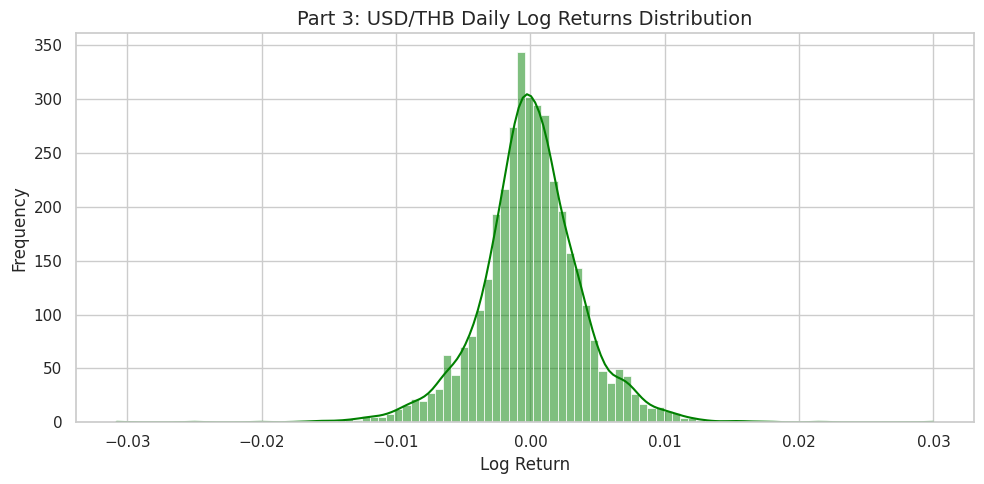

In [5]:
# 1. Calculate USD/THB Log Returns
df['THB_Log_Return'] = np.log(df['USDTHB'] / df['USDTHB'].shift(1))

# 2. Plot USD/THB Log Returns Distribution
plt.figure(figsize=(10, 5))

sns.histplot(df['THB_Log_Return'].dropna(), kde=True, color='green', bins=100)

plt.title('Part 3: USD/THB Daily Log Returns Distribution', fontsize=14)
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **4. Normalized vix ($Z_{vix}$)**

Following our previous discussion, to maintain stationarity without losing the "absolute fear" context that raw log returns might obscure, use a Z-Score or a Moving Average Spread of the vix.
* Formula: $Z_{vix} = \frac{vix - \mu_{vix}}{\sigma_{vix}}$
* Role: Acts as a leading indicator. If the vix Z-score spikes, the Manager knows a transition to a High Volatility regime is highly probable, even before the Thai Gold price reacts.

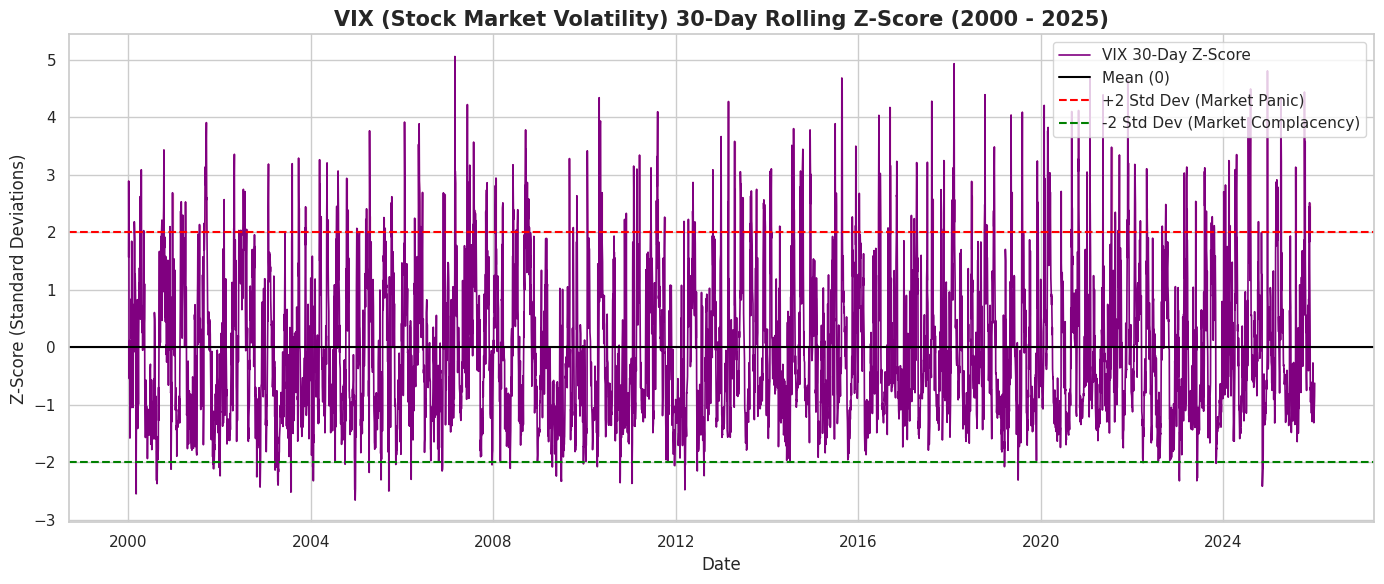

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load and Clean VIX Data
# ---------------------------------------------------------
vix_df = pd.read_csv("VIX_History.csv")

# Ensure proper Datetime formatting and chronologically sort the index
vix_df['DATE'] = pd.to_datetime(vix_df['DATE'])
vix_df.set_index('DATE', inplace=True)
vix_df.sort_index(inplace=True)

# ---------------------------------------------------------
# 2. Calculate the VIX 30-Day Rolling Z-Score
# ---------------------------------------------------------
window = 30
vix_mean = vix_df['CLOSE'].rolling(window=window).mean()
vix_std = vix_df['CLOSE'].rolling(window=window).std()

vix_df['VIX_30D_Z_Score'] = (vix_df['CLOSE'] - vix_mean) / vix_std

# Drop NaN values and filter for the 2000 to 2025 timeframe
vix_clean = vix_df.dropna(subset=['VIX_30D_Z_Score'])
vix_filtered = vix_clean.loc['2000-01-01':'2025-12-31']

# ---------------------------------------------------------
# 3. Plot the VIX Z-Score
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot the main line
plt.plot(vix_filtered.index, vix_filtered['VIX_30D_Z_Score'], color='purple', linewidth=1.2, label='VIX 30-Day Z-Score')

# Add Standard Deviation reference lines
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Mean (0)')
plt.axhline(2, color='red', linestyle='--', linewidth=1.5, label='+2 Std Dev (Market Panic)')
plt.axhline(-2, color='green', linestyle='--', linewidth=1.5, label='-2 Std Dev (Market Complacency)')

# Fill extreme volatility zones
plt.fill_between(vix_filtered.index, vix_filtered['VIX_30D_Z_Score'], 2,
                 where=(vix_filtered['VIX_30D_Z_Score'] > 2), color='red', alpha=0.3)
plt.fill_between(vix_filtered.index, vix_filtered['VIX_30D_Z_Score'], -2,
                 where=(vix_filtered['VIX_30D_Z_Score'] < -2), color='green', alpha=0.3)

plt.title('VIX (Stock Market Volatility) 30-Day Rolling Z-Score (2000 - 2025)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Z-Score (Standard Deviations)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# **5. Normalized gvz ($Z_{gvz}$)**
Following our previous discussion, to maintain stationarity without losing the "absolute fear" context that raw log returns might obscure, use a Z-Score or a Moving Average Spread of the gvz.
* Formula: $Z_{gvz} = \frac{gvz - \mu_{gvz}}{\sigma_{gvz}}$
* Role: Acts as a leading indicator. If the vix Z-score spikes, the Manager knows a transition to a High Volatility regime is highly probable, even before the Thai Gold price reacts.

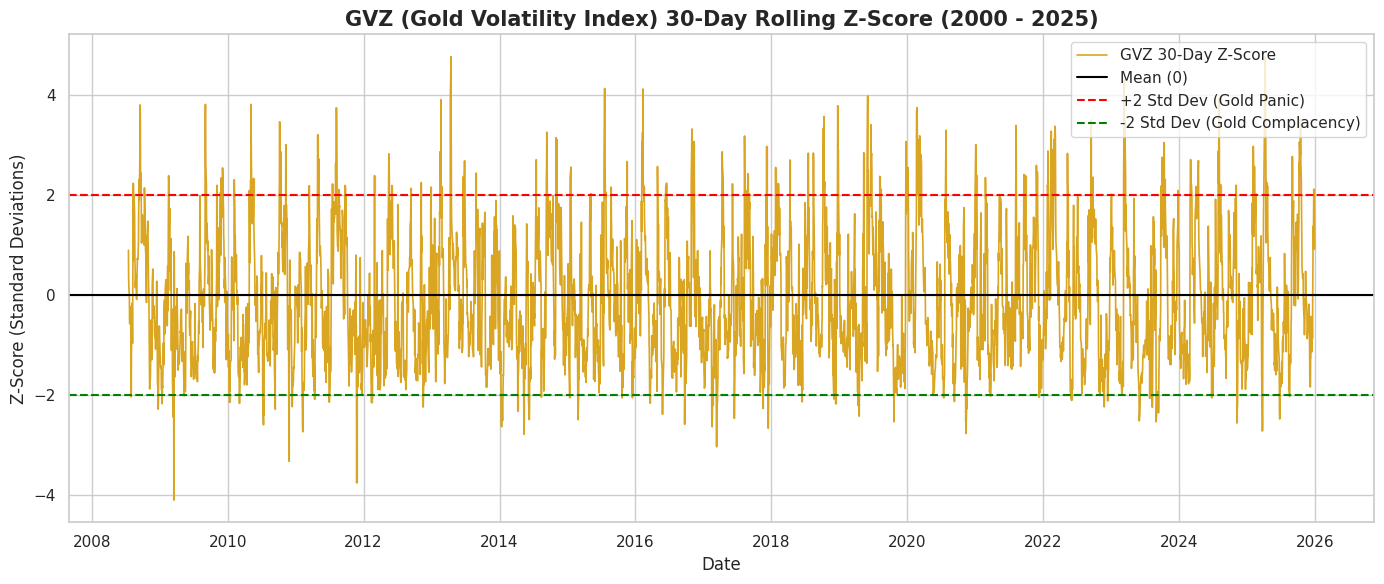

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load and Clean GVZ Data
# ---------------------------------------------------------
gvz_df = pd.read_csv("CBOE_Gold_Volatitity_Historical_Data.csv")

# Ensure proper Datetime formatting and chronologically sort the index
gvz_df['Date'] = pd.to_datetime(gvz_df['Date'])
gvz_df.set_index('Date', inplace=True)
gvz_df.sort_index(inplace=True)

# ---------------------------------------------------------
# 2. Calculate the GVZ 30-Day Rolling Z-Score
# ---------------------------------------------------------
window = 30
gvz_mean = gvz_df['Price'].rolling(window=window).mean()
gvz_std = gvz_df['Price'].rolling(window=window).std()

gvz_df['GVZ_30D_Z_Score'] = (gvz_df['Price'] - gvz_mean) / gvz_std

# Drop NaN values and filter for the 2000 to 2025 timeframe
gvz_clean = gvz_df.dropna(subset=['GVZ_30D_Z_Score'])
gvz_filtered = gvz_clean.loc['2000-01-01':'2025-12-31']

# ---------------------------------------------------------
# 3. Plot the GVZ Z-Score
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot the main line
plt.plot(gvz_filtered.index, gvz_filtered['GVZ_30D_Z_Score'], color='goldenrod', linewidth=1.2, label='GVZ 30-Day Z-Score')

# Add Standard Deviation reference lines
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Mean (0)')
plt.axhline(2, color='red', linestyle='--', linewidth=1.5, label='+2 Std Dev (Gold Panic)')
plt.axhline(-2, color='green', linestyle='--', linewidth=1.5, label='-2 Std Dev (Gold Complacency)')

# Fill extreme volatility zones
plt.fill_between(gvz_filtered.index, gvz_filtered['GVZ_30D_Z_Score'], 2,
                 where=(gvz_filtered['GVZ_30D_Z_Score'] > 2), color='red', alpha=0.3)
plt.fill_between(gvz_filtered.index, gvz_filtered['GVZ_30D_Z_Score'], -2,
                 where=(gvz_filtered['GVZ_30D_Z_Score'] < -2), color='green', alpha=0.3)

plt.title('GVZ (Gold Volatility Index) 30-Day Rolling Z-Score (2000 - 2025)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Z-Score (Standard Deviations)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

 # **6. Global Gold lag1 Log Returns ($r_{LAGXAU}$)**

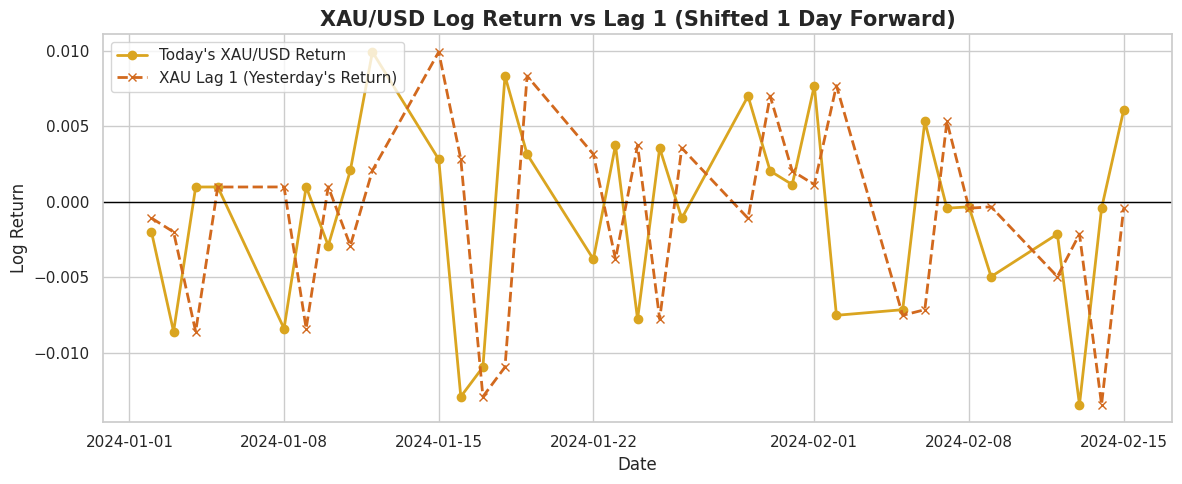

In [8]:


# 2. Format Datetime and Set Index
xauusd_df['Datetime'] = pd.to_datetime(xauusd_df['<DATE>'], format='%Y.%m.%d')
usdthb_df['Datetime'] = pd.to_datetime(usdthb_df['<DATE>'], format='%Y.%m.%d')

xauusd_df.set_index('Datetime', inplace=True)
usdthb_df.set_index('Datetime', inplace=True)
xauusd_df.sort_index(inplace=True)
usdthb_df.sort_index(inplace=True)

# 3. Merge Datasets
df = xauusd_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'XAUUSD'}).join(
    usdthb_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'USDTHB'}), how='inner'
)

# 4. Calculate XAU/USD Base Log Return
df['XAU_Log_Return'] = np.log(df['XAUUSD'] / df['XAUUSD'].shift(1))

# 5. Generate Lag 1 Feature
df['XAU_Lag1'] = df['XAU_Log_Return'].shift(1)

# Clean Data & Zoom for visualization (First 1.5 Months of 2024)
df_clean = df.dropna().copy()
zoom_df = df_clean.loc['2024-01-01':'2024-02-15']

# 6. Plotting XAU/USD Lag Feature
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot Today's return vs Yesterday's return (Lag 1)
plt.plot(zoom_df.index, zoom_df['XAU_Log_Return'], marker='o', color='goldenrod', linewidth=2, label="Today's XAU/USD Return")
plt.plot(zoom_df.index, zoom_df['XAU_Lag1'], marker='x', color='chocolate', linestyle='--', linewidth=2, label="XAU Lag 1 (Yesterday's Return)")

plt.title('XAU/USD Log Return vs Lag 1 (Shifted 1 Day Forward)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

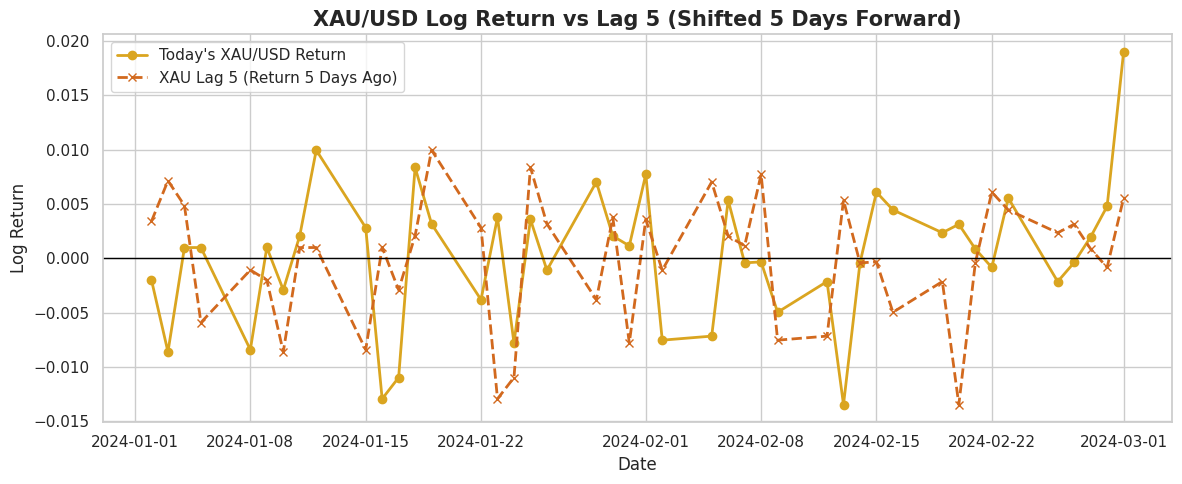

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
xauusd_df = pd.read_csv("XAUUSD_Daily_200406110000_202512310000.csv")
usdthb_df = pd.read_csv("USDTHB_Daily_201106020000_202512310000.csv")

# 2. Format Datetime and Set Index
xauusd_df['Datetime'] = pd.to_datetime(xauusd_df['<DATE>'], format='%Y.%m.%d')
usdthb_df['Datetime'] = pd.to_datetime(usdthb_df['<DATE>'], format='%Y.%m.%d')

xauusd_df.set_index('Datetime', inplace=True)
usdthb_df.set_index('Datetime', inplace=True)
xauusd_df.sort_index(inplace=True)
usdthb_df.sort_index(inplace=True)

# 3. Merge Datasets
df = xauusd_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'XAUUSD'}).join(
    usdthb_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'USDTHB'}), how='inner'
)

# 4. Calculate XAU/USD Base Log Return
df['XAU_Log_Return'] = np.log(df['XAUUSD'] / df['XAUUSD'].shift(1))

# 5. Generate Lag 5 Feature (5 Days Before)
df['XAU_Lag5'] = df['XAU_Log_Return'].shift(5)

# Clean Data & Zoom for visualization (First 2 Months of 2024 to see the 5-day shift clearly)
df_clean = df.dropna().copy()
zoom_df = df_clean.loc['2024-01-01':'2024-03-01']

# 6. Plotting XAU/USD Lag 5 Feature
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot Today's return vs 5 Days Ago return (Lag 5)
plt.plot(zoom_df.index, zoom_df['XAU_Log_Return'], marker='o', color='goldenrod', linewidth=2, label="Today's XAU/USD Return")
plt.plot(zoom_df.index, zoom_df['XAU_Lag5'], marker='x', color='chocolate', linestyle='--', linewidth=2, label="XAU Lag 5 (Return 5 Days Ago)")

plt.title('XAU/USD Log Return vs Lag 5 (Shifted 5 Days Forward)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

# **7. USD/THB lag1 Log Returns ($r_{LAGTHB}$)**

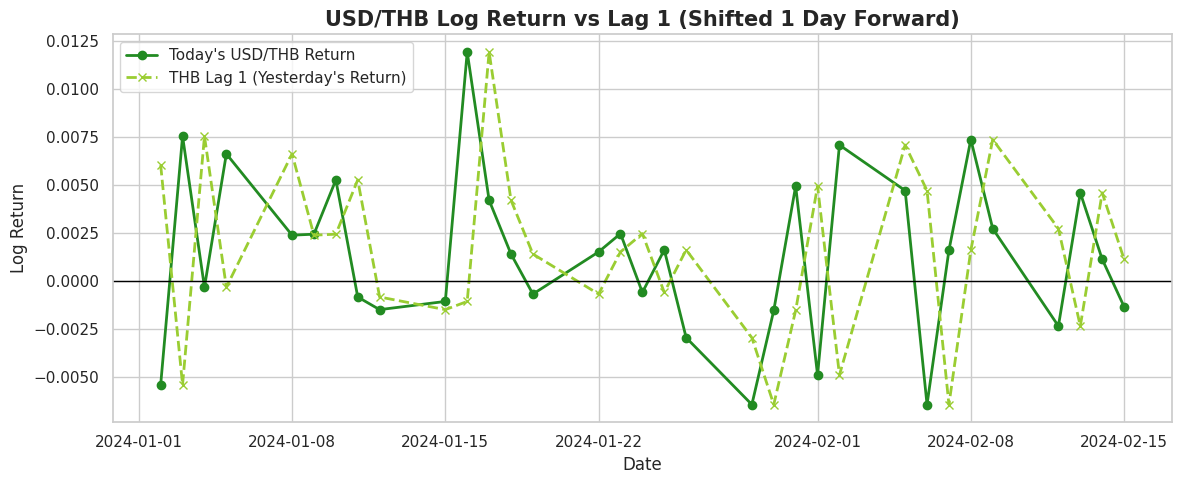

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate USD/THB Base Log Return
df['THB_Log_Return'] = np.log(df['USDTHB'] / df['USDTHB'].shift(1))

# 2. Generate Lag 1 Feature
df['THB_Lag1'] = df['THB_Log_Return'].shift(1)

# Clean Data & Zoom for visualization (First 1.5 Months of 2024)
df_clean = df.dropna().copy()
zoom_df = df_clean.loc['2024-01-01':'2024-02-15']

# 3. Plotting USD/THB Lag Feature
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot Today's return vs Yesterday's return (Lag 1)
plt.plot(zoom_df.index, zoom_df['THB_Log_Return'], marker='o', color='forestgreen', linewidth=2, label="Today's USD/THB Return")
plt.plot(zoom_df.index, zoom_df['THB_Lag1'], marker='x', color='yellowgreen', linestyle='--', linewidth=2, label="THB Lag 1 (Yesterday's Return)")

plt.title('USD/THB Log Return vs Lag 1 (Shifted 1 Day Forward)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

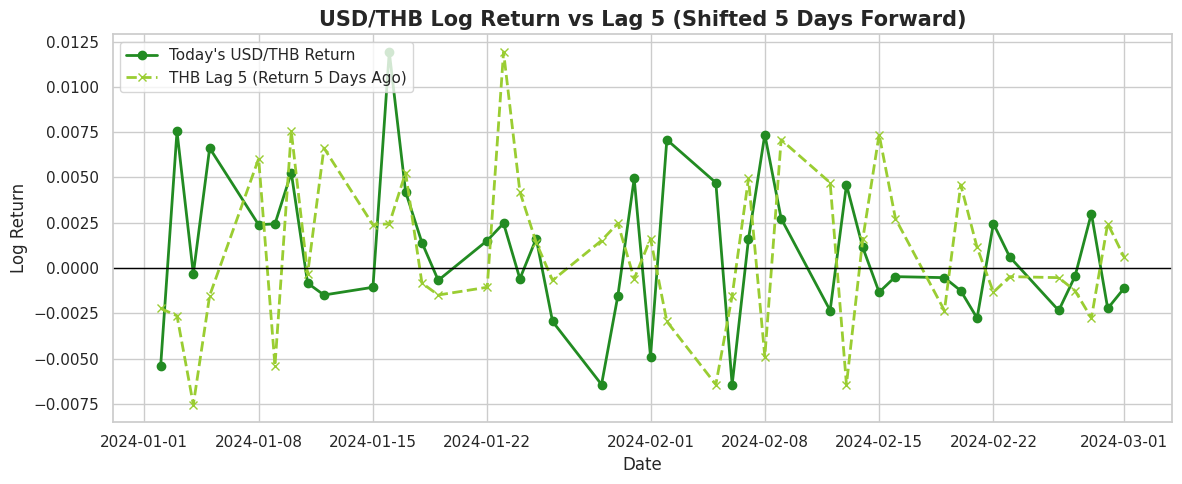

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate USD/THB Base Log Return
df['THB_Log_Return'] = np.log(df['USDTHB'] / df['USDTHB'].shift(1))

# 2. Generate Lag 5 Feature (5 Days Before)
df['THB_Lag5'] = df['THB_Log_Return'].shift(5)

# Clean Data & Zoom for visualization (First 2 Months of 2024)
df_clean = df.dropna().copy()
zoom_df = df_clean.loc['2024-01-01':'2024-03-01']

# 3. Plotting USD/THB Lag 5 Feature
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot Today's return vs 5 Days Ago return (Lag 5)
plt.plot(zoom_df.index, zoom_df['THB_Log_Return'], marker='o', color='forestgreen', linewidth=2, label="Today's USD/THB Return")
plt.plot(zoom_df.index, zoom_df['THB_Lag5'], marker='x', color='yellowgreen', linestyle='--', linewidth=2, label="THB Lag 5 (Return 5 Days Ago)")

plt.title('USD/THB Log Return vs Lag 5 (Shifted 5 Days Forward)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()